In [2]:
# 데이터 처리 및 분석
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import warnings

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 통계 분석
from scipy import stats
from scipy.stats import shapiro, levene, ttest_ind, chi2_contingency, f_oneway
from scipy.stats import mannwhitneyu, fisher_exact, kruskal
from statsmodels.stats.multicomp import pairwise_tukeyhsd, MultiComparison
import pingouin as pg

# 출력 설정
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)


# 한글 폰트 설정
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # maxOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'
    
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)

# 시드 설정
np.random.seed(42)

print("="*60)
print("라이브러리 로드 완료!")
print("한글 폰트 설정 완료!")
print("="*60)

라이브러리 로드 완료!
한글 폰트 설정 완료!


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

SB_DEEP_GREEN = '#1E3932'
SB_GREEN      = '#006241'
SB_LIGHT_GREEN = '#D4E9E2'
SB_GOLD       = '#CBA258'
SB_GREY       = '#A2AAAD'
SB_BLACK      = '#27251F'

plt.rcParams.update({
    'font.family': 'Malgun Gothic',
    'axes.unicode_minus': False,
    'text.color': SB_BLACK,
    'axes.labelcolor': SB_BLACK,
    'xtick.color': SB_BLACK,
    'ytick.color': SB_BLACK,
    'axes.spines.top': False,    
    'axes.spines.right': False, 
    'patch.edgecolor': 'none'    
})


sns.set_palette([SB_GREEN, SB_GOLD, SB_DEEP_GREEN, SB_LIGHT_GREEN, SB_GREY])

In [4]:
merge_df = pd.read_csv("../../Data/merged_df_260325.csv")

In [ ]:
# 오퍼+결제 만들기
# 1. 오퍼 완료(completed) 기록만 쏙 골라내기
completed_df = merge_df[merge_df['event'] == 'completed']

# 2. 결제(transaction) 기록에서 병합에 쓸 '고객', '시간' 그리고 우리가 찾던 '매출(amount)'만 가져오기
transaction_df = merge_df[merge_df['event'] == 'transaction'][['person', 'time', 'amount']]

# 3. Merge 'person'과 'time'이 일치하는 데이터끼리 붙여주기
offer_linked_df = pd.merge(completed_df, transaction_df, on=['person', 'time'], how='inner')

# 상위 3개 확인해보기
display(offer_linked_df[['person', 'time', 'offer_label', 'amount_y']].head(3))

,person,time,offer_label,amount_y
0,0009655768c64bdeb2e877511632db8f,576,discount_4,10.27
1,0009655768c64bdeb2e877511632db8f,414,bogo_4,8.57
2,0009655768c64bdeb2e877511632db8f,528,discount_3,14.11


In [ ]:
# 일반 결제 매출 구하기
# 1. 전체 결제(transaction) 데이터 준비
transaction_df = merge_df[merge_df['event'] == 'transaction'][['person', 'time', 'amount']]

# 2. 아까 구한 '오퍼 연계 결제' 데이터에서 기준이 되는 고객과 시간만 가져오기 (중복 제거)
linked_keys = offer_linked_df[['person', 'time']].drop_duplicates()

# 3. 전체 결제에 오퍼 연계 결제 정보를 Left 조인으로 붙이되, indicator=True를 써서 출처 표시하기
regular_transaction_df = pd.merge(transaction_df, linked_keys, on=['person', 'time'], how='left', indicator=True)

# 4. '_merge' 컬럼이 'left_only'인 것(전체 결제에는 있는데 오퍼 결제에는 없는 것)만 골라내기
regular_transaction_df = regular_transaction_df[regular_transaction_df['_merge'] == 'left_only']

# 5. 보기 싫은 '_merge' 컬럼은 지워주기
regular_transaction_df = regular_transaction_df.drop(columns=['_merge'])

# 잘 분리되었는지 상위 3개 슬쩍 확인해보기
display(regular_transaction_df.head(3))

,person,time,amount
0,0009655768c64bdeb2e877511632db8f,228,22.16
3,0009655768c64bdeb2e877511632db8f,552,13.56
5,0009655768c64bdeb2e877511632db8f,660,12.36


In [7]:
# 'offer_label'에 'informational'이 포함되지 않은 오퍼만 남기기
# na=False는 값이 비어있는(NaN) 경우 에러를 방지해줍니다.
valid_offers = merge_df[~merge_df['offer_label'].str.contains('informational', na=False)]

# 1. 오퍼별 총 발송 수 계산 (event == 'received')
sent_counts = valid_offers[valid_offers['event'] == 'received'].groupby('offer_label').size().reset_index(name='총발송수')

# 발송 수 기준으로 내림차순 정렬
sent_counts = sent_counts.sort_values(by='총발송수', ascending=False).reset_index(drop=True)

# 결과 확인
display(sent_counts)

,offer_label,총발송수
0,bogo_3,7677
1,discount_1,7668
2,bogo_1,7658
3,discount_2,7646
4,discount_4,7632
5,discount_3,7597
6,bogo_2,7593
7,bogo_4,7571


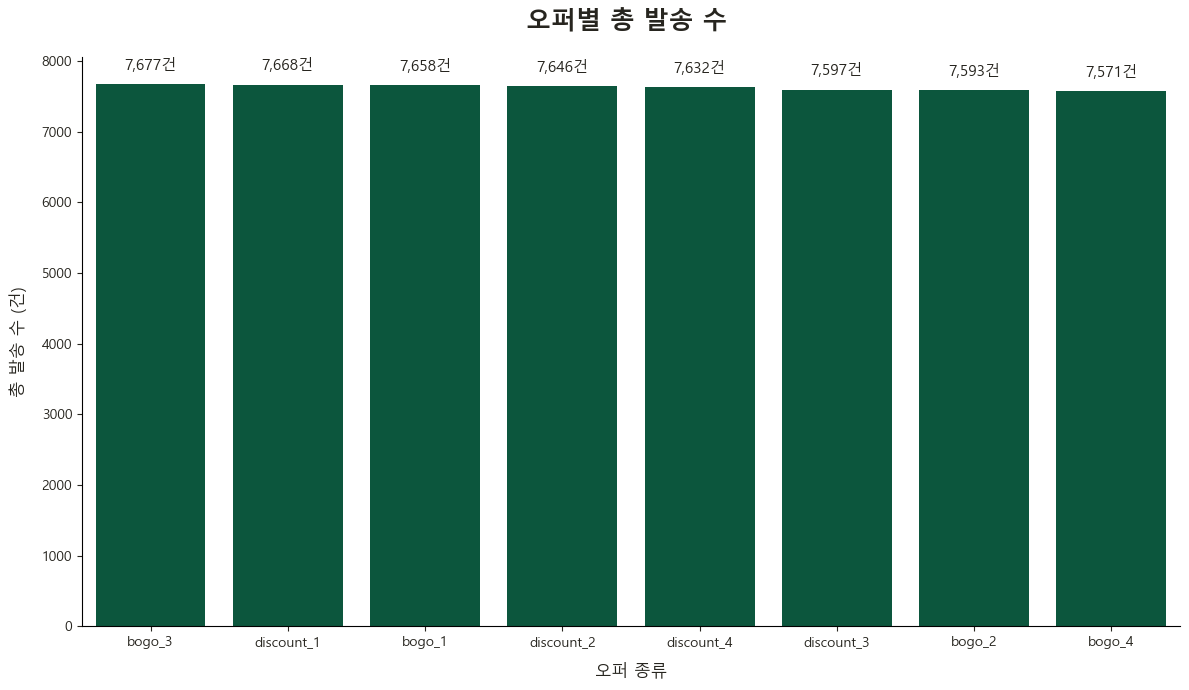

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# 스타벅스 컬러 설정 
SB_DEEP_GREEN  = '#1E3932'
SB_GREEN       = '#006241'
SB_LIGHT_GREEN = '#D4E9E2'
SB_GOLD        = '#CBA258'
SB_GREY        = '#A2AAAD'
SB_BLACK       = '#27251F'

plt.rcParams.update({
    'font.family': 'Malgun Gothic', # 맥북이시면 'AppleGothic'
    'axes.unicode_minus': False,
    'text.color': SB_BLACK,
    'axes.labelcolor': SB_BLACK,
    'xtick.color': SB_BLACK,
    'ytick.color': SB_BLACK,
    'axes.spines.top': False,    
    'axes.spines.right': False, 
    'patch.edgecolor': 'none'    
})

plt.figure(figsize=(12, 7))

# 막대그래프 그리기
ax = sns.barplot(data=sent_counts, x='offer_label', y='총발송수', color=SB_GREEN)

plt.title('오퍼별 총 발송 수 ', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('오퍼 종류', fontsize=12, labelpad=10) 
plt.ylabel('총 발송 수 (건)', fontsize=12, labelpad=10)

# 막대 '위'에 숫자 달아주기
for i, v in enumerate(sent_counts['총발송수']):
    ax.text(i, v + 200, f"{v:,}건", color=SB_BLACK, ha='center', fontsize=11)

plt.tight_layout()
plt.show()

In [ ]:
# 인포메이셔널 제외 필터링
valid_offers = merge_df[~merge_df['offer_label'].str.contains('informational', na=False)]

# 2. 오퍼별 총 열람 수 계산 (event == 'viewed')
viewed_counts = valid_offers[valid_offers['event'] == 'viewed'].groupby('offer_label').size().reset_index(name='총열람수')

# 열람 수 기준으로 내림차순 정렬
viewed_counts = viewed_counts.sort_values(by='총열람수', ascending=False).reset_index(drop=True)

# 결과 확인
display(viewed_counts)

,offer_label,총열람수
0,discount_2,7337
1,discount_3,7327
2,bogo_2,7298
3,bogo_4,7264
4,bogo_1,6716
5,bogo_3,4171
6,discount_4,4118
7,discount_1,2663


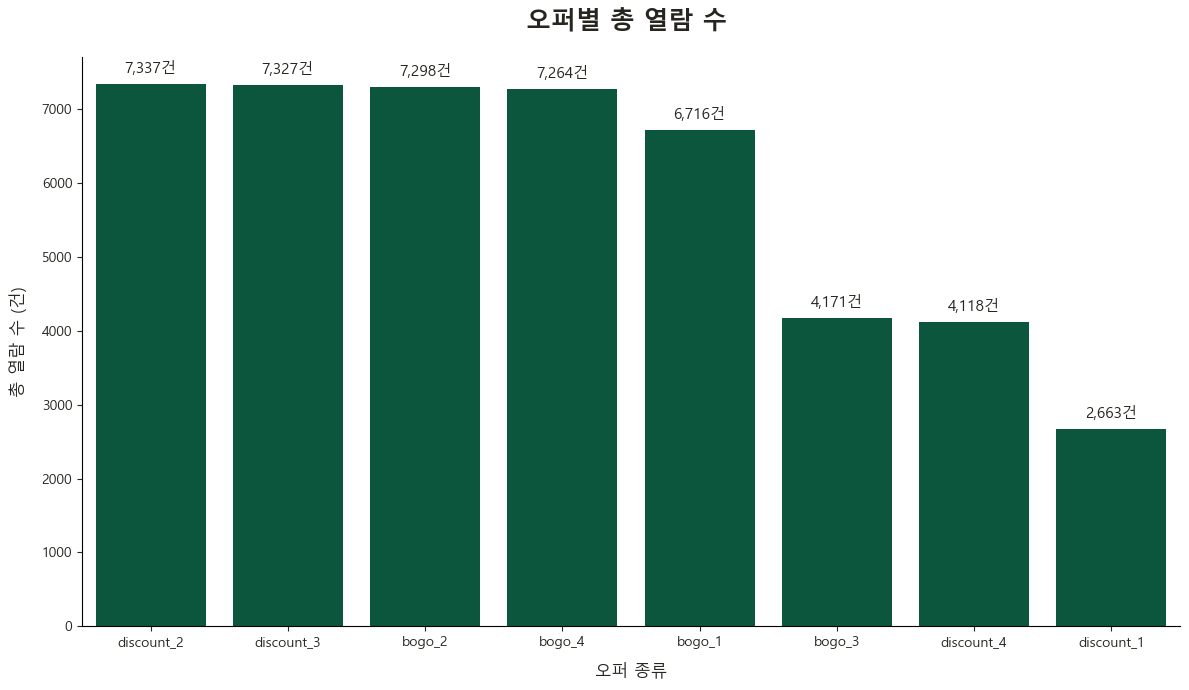

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# 스타벅스 컬러 설정 
SB_DEEP_GREEN  = '#1E3932'
SB_GREEN       = '#006241'
SB_LIGHT_GREEN = '#D4E9E2'
SB_GOLD        = '#CBA258'
SB_GREY        = '#A2AAAD'
SB_BLACK       = '#27251F'

plt.rcParams.update({
    'font.family': 'Malgun Gothic', # 맥북이시면 'AppleGothic'
    'axes.unicode_minus': False,
    'text.color': SB_BLACK,
    'axes.labelcolor': SB_BLACK,
    'xtick.color': SB_BLACK,
    'ytick.color': SB_BLACK,
    'axes.spines.top': False,    
    'axes.spines.right': False, 
    'patch.edgecolor': 'none'    
})

plt.figure(figsize=(12, 7))

# 막대그래프 그리기
ax = sns.barplot(data=viewed_counts, x='offer_label', y='총열람수', color=SB_GREEN)

plt.title('오퍼별 총 열람 수 ', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('오퍼 종류', fontsize=12, labelpad=10) 
plt.ylabel('총 열람 수 (건)', fontsize=12, labelpad=10)

# 막대 '위'에 숫자 달아주기
for i, v in enumerate(viewed_counts['총열람수']):
    ax.text(i, v + 150, f"{v:,}건", color=SB_BLACK, ha='center', fontsize=11)

plt.tight_layout()
plt.show()

In [ ]:
# 인포메이셔널 제외 필터링
valid_offers = merge_df[~merge_df['offer_label'].str.contains('informational', na=False)]

# 3. 오퍼별 총 완료 수 계산 (event == 'completed')
completed_counts = valid_offers[valid_offers['event'] == 'completed'].groupby('offer_label').size().reset_index(name='총완료수')

# 완료 수 기준으로 내림차순 정렬
completed_counts = completed_counts.sort_values(by='총완료수', ascending=False).reset_index(drop=True)

# 결과 확인
display(completed_counts)

,offer_label,총완료수
0,discount_3,5265
1,discount_2,5112
2,bogo_3,4303
3,bogo_4,4262
4,discount_4,3964
5,bogo_1,3635
6,discount_1,3340
7,bogo_2,3301


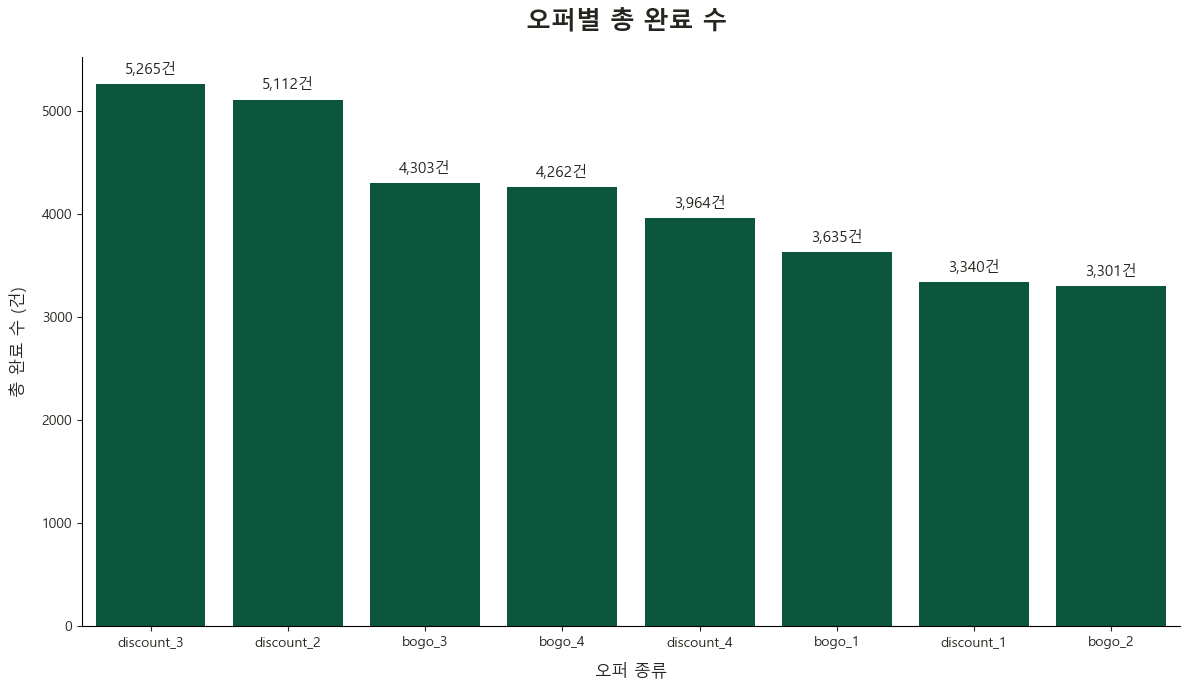

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# 스타벅스 컬러 설정 
SB_DEEP_GREEN  = '#1E3932'
SB_GREEN       = '#006241'
SB_LIGHT_GREEN = '#D4E9E2'
SB_GOLD        = '#CBA258'
SB_GREY        = '#A2AAAD'
SB_BLACK       = '#27251F'

plt.rcParams.update({
    'font.family': 'Malgun Gothic', # 맥북이시면 'AppleGothic'
    'axes.unicode_minus': False,
    'text.color': SB_BLACK,
    'axes.labelcolor': SB_BLACK,
    'xtick.color': SB_BLACK,
    'ytick.color': SB_BLACK,
    'axes.spines.top': False,    
    'axes.spines.right': False, 
    'patch.edgecolor': 'none'    
})

plt.figure(figsize=(12, 7))

# 막대그래프 그리기
ax = sns.barplot(data=completed_counts, x='offer_label', y='총완료수', color=SB_GREEN)

plt.title('오퍼별 총 완료 수 ', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('오퍼 종류', fontsize=12, labelpad=10) 
plt.ylabel('총 완료 수 (건)', fontsize=12, labelpad=10)

# 막대 '위'에 숫자 달아주기
for i, v in enumerate(completed_counts['총완료수']):
    ax.text(i, v + 100, f"{v:,}건", color=SB_BLACK, ha='center', fontsize=11)

plt.tight_layout()
plt.show()

In [ ]:
# 인포메이셔널 제외 필터링
valid_offers = merge_df[~merge_df['offer_label'].str.contains('informational', na=False)]

# 1. 오퍼별 총 발송 수 집계
sent_counts = valid_offers[valid_offers['event'] == 'received'].groupby('offer_label').size().reset_index(name='총발송수')

# 2. 오퍼별 총 완료 수 집계
completed_counts = valid_offers[valid_offers['event'] == 'completed'].groupby('offer_label').size().reset_index(name='총완료수')

# 3. 데이터 병합 (발송 수 데이터에 완료 수 데이터 붙이기)
rate_df = pd.merge(sent_counts, completed_counts, on='offer_label', how='left')

# (혹시 완료가 0건이라 비어있는 값이 있다면 0으로 채워주기)
rate_df['총완료수'] = rate_df['총완료수'].fillna(0)

# 4. 전체 완료율(%) 계산! (총 완료 수 / 총 발송 수 * 100)
rate_df['완료율(%)'] = (rate_df['총완료수'] / rate_df['총발송수']) * 100

# 완료율 기준으로 내림차순 정렬
rate_df = rate_df.sort_values(by='완료율(%)', ascending=False).reset_index(drop=True)

# 결과 확인
display(rate_df)

,offer_label,총발송수,총완료수,완료율(%)
0,discount_3,7597,5265,69.303673
1,discount_2,7646,5112,66.858488
2,bogo_4,7571,4262,56.293752
3,bogo_3,7677,4303,56.050541
4,discount_4,7632,3964,51.939203
5,bogo_1,7658,3635,47.466701
6,discount_1,7668,3340,43.557642
7,bogo_2,7593,3301,43.474253


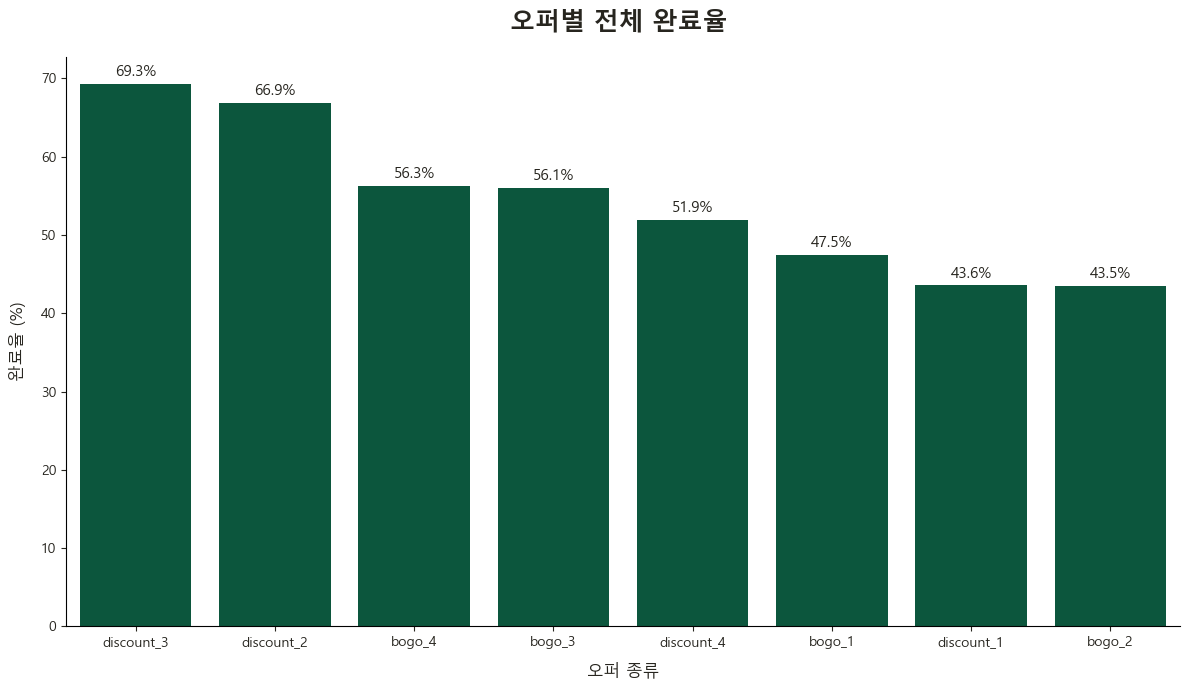

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# 스타벅스 컬러 설정 
SB_DEEP_GREEN  = '#1E3932'
SB_GREEN       = '#006241'
SB_LIGHT_GREEN = '#D4E9E2'
SB_GOLD        = '#CBA258'
SB_GREY        = '#A2AAAD'
SB_BLACK       = '#27251F'

plt.rcParams.update({
    'font.family': 'Malgun Gothic', # 맥북이시면 'AppleGothic'
    'axes.unicode_minus': False,
    'text.color': SB_BLACK,
    'axes.labelcolor': SB_BLACK,
    'xtick.color': SB_BLACK,
    'ytick.color': SB_BLACK,
    'axes.spines.top': False,    
    'axes.spines.right': False, 
    'patch.edgecolor': 'none'    
})

plt.figure(figsize=(12, 7))

# 막대그래프 그리기 (Y축은 완료율!)
ax = sns.barplot(data=rate_df, x='offer_label', y='완료율(%)', color=SB_GREEN)

plt.title('오퍼별 전체 완료율 ', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('오퍼 종류', fontsize=12, labelpad=10) 
plt.ylabel('완료율 (%)', fontsize=12, labelpad=10)

# 막대 '위'에 숫자(% 포함, 소수점 첫째자리까지) 달아주기
for i, v in enumerate(rate_df['완료율(%)']):
    ax.text(i, v + 1, f"{v:.1f}%", color=SB_BLACK, ha='center', fontsize=11)

plt.tight_layout()
plt.show()

In [20]:
# 1. 인포메이셔널 제외 필터링
valid_offers = merge_df[~merge_df['offer_label'].str.contains('informational', na=False)]

# 2. 발송 수 집계
sent_counts = valid_offers[valid_offers['event'] == 'received'].groupby('offer_label').size().reset_index(name='총발송수')

# 3. 오퍼 연계 매출 집계 (완료 + 결제 병합)
completed_df = valid_offers[valid_offers['event'] == 'completed']
transaction_df = merge_df[merge_df['event'] == 'transaction'][['person', 'time', 'amount']]
offer_linked_df = pd.merge(completed_df, transaction_df, on=['person', 'time'], how='inner')
revenue_by_offer = offer_linked_df.groupby('offer_label')['amount_y'].sum().reset_index(name='총연계매출')

# 4. 두 데이터 병합 및 계산! (총연계매출 ÷ 총발송수)
avg_df = pd.merge(sent_counts, revenue_by_offer, on='offer_label', how='left')

# (혹시 매출이 0인 곳이 있으면 결측치가 생기므로 0으로 채우기)
avg_df['총연계매출'] = avg_df['총연계매출'].fillna(0)

# 대망의 발송 1건당 평균 매출 계산
avg_df['발송1건당_평균매출'] = avg_df['총연계매출'] / avg_df['총발송수']

# 매출이 높은 순서대로 내림차순 정렬
avg_df = avg_df.sort_values(by='발송1건당_평균매출', ascending=False).reset_index(drop=True)

# 결과 확인
display(avg_df)

,offer_label,총발송수,총연계매출,발송1건당_평균매출
0,discount_3,7597,96900.08,12.755045
1,discount_2,7646,89848.17,11.751003
2,bogo_1,7658,87109.94,11.375025
3,discount_1,7668,85985.53,11.213554
4,bogo_4,7571,83146.93,10.982292
5,discount_4,7632,81687.95,10.703348
6,bogo_2,7593,78562.14,10.346653
7,bogo_3,7677,77066.31,10.038597


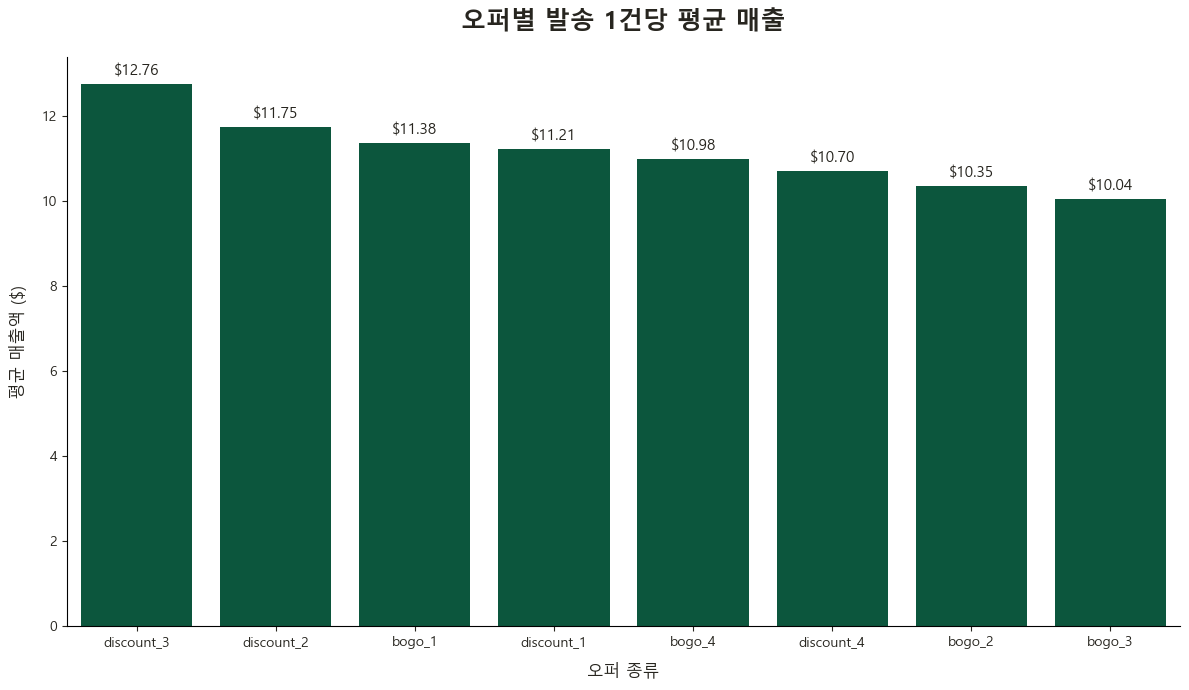

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# 스타벅스 컬러 설정 
SB_DEEP_GREEN  = '#1E3932'
SB_GREEN       = '#006241'
SB_LIGHT_GREEN = '#D4E9E2'
SB_GOLD        = '#CBA258'
SB_GREY        = '#A2AAAD'
SB_BLACK       = '#27251F'

plt.rcParams.update({
    'font.family': 'Malgun Gothic', # 맥북이시면 'AppleGothic'
    'axes.unicode_minus': False,
    'text.color': SB_BLACK,
    'axes.labelcolor': SB_BLACK,
    'xtick.color': SB_BLACK,
    'ytick.color': SB_BLACK,
    'axes.spines.top': False,    
    'axes.spines.right': False, 
    'patch.edgecolor': 'none'    
})

plt.figure(figsize=(12, 7))

# 막대그래프 그리기
ax = sns.barplot(data=avg_df, x='offer_label', y='발송1건당_평균매출', color=SB_GREEN)

plt.title('오퍼별 발송 1건당 평균 매출', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('오퍼 종류', fontsize=12, labelpad=10) 
plt.ylabel('평균 매출액 ($)', fontsize=12, labelpad=10)

# 막대 '위'에 숫자 달아주기 (달러 기호 $와 소수점 둘째 자리까지 표현!)
for i, v in enumerate(avg_df['발송1건당_평균매출']):
    ax.text(i, v + 0.2, f"${v:.2f}", color=SB_BLACK, ha='center', fontsize=11)

plt.tight_layout()
plt.show()

In [22]:
# 1. 인포메이셔널 제외 필터링
valid_offers = merge_df[~merge_df['offer_label'].str.contains('informational', na=False)]

# 2. 오퍼별 총 '완료 수' 집계
completed_counts = valid_offers[valid_offers['event'] == 'completed'].groupby('offer_label').size().reset_index(name='총완료수')

# 3. 오퍼 연계 매출 집계 (완료 + 결제 병합)
completed_df = valid_offers[valid_offers['event'] == 'completed']
transaction_df = merge_df[merge_df['event'] == 'transaction'][['person', 'time', 'amount']]
offer_linked_df = pd.merge(completed_df, transaction_df, on=['person', 'time'], how='inner')
revenue_by_offer = offer_linked_df.groupby('offer_label')['amount_y'].sum().reset_index(name='총연계매출')

# 4. 두 데이터 병합 및 계산! (총연계매출 ÷ 총완료수)
avg_completed_df = pd.merge(completed_counts, revenue_by_offer, on='offer_label', how='left')

# 결측치 방지용 0 채우기
avg_completed_df['총연계매출'] = avg_completed_df['총연계매출'].fillna(0)

# 대망의 완료 1건당 평균 매출 계산
avg_completed_df['완료1건당_평균매출'] = avg_completed_df['총연계매출'] / avg_completed_df['총완료수']

# 매출이 높은 순서대로 내림차순 정렬
avg_completed_df = avg_completed_df.sort_values(by='완료1건당_평균매출', ascending=False).reset_index(drop=True)

# 결과 확인
display(avg_completed_df)

,offer_label,총완료수,총연계매출,완료1건당_평균매출
0,discount_1,3340,85985.53,25.744171
1,bogo_1,3635,87109.94,23.964220
2,bogo_2,3301,78562.14,23.799497
3,discount_4,3964,81687.95,20.607455
4,bogo_4,4262,83146.93,19.508900
5,discount_3,5265,96900.08,18.404574
6,bogo_3,4303,77066.31,17.909902
7,discount_2,5112,89848.17,17.575933


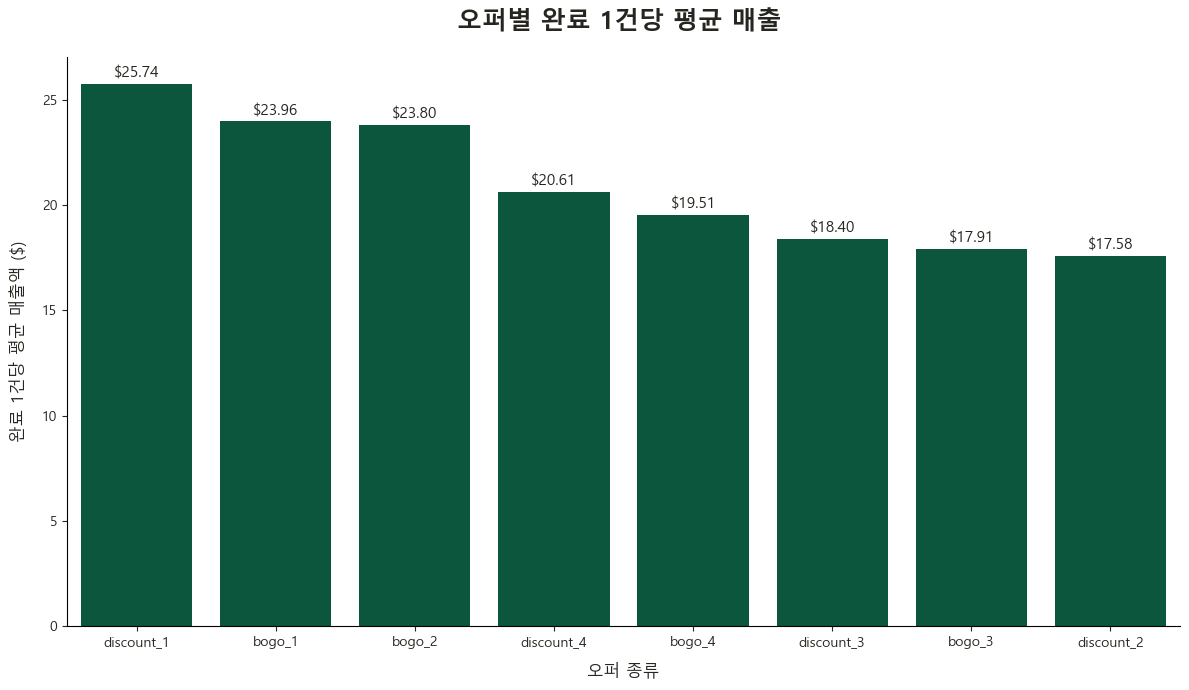

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# 스타벅스 컬러 설정 
SB_DEEP_GREEN  = '#1E3932'
SB_GREEN       = '#006241'
SB_LIGHT_GREEN = '#D4E9E2'
SB_GOLD        = '#CBA258'
SB_GREY        = '#A2AAAD'
SB_BLACK       = '#27251F'

plt.rcParams.update({
    'font.family': 'Malgun Gothic', # 맥북이시면 'AppleGothic'
    'axes.unicode_minus': False,
    'text.color': SB_BLACK,
    'axes.labelcolor': SB_BLACK,
    'xtick.color': SB_BLACK,
    'ytick.color': SB_BLACK,
    'axes.spines.top': False,    
    'axes.spines.right': False, 
    'patch.edgecolor': 'none'    
})

plt.figure(figsize=(12, 7))

# 막대그래프 그리기
ax = sns.barplot(data=avg_completed_df, x='offer_label', y='완료1건당_평균매출', color=SB_GREEN)

plt.title('오퍼별 완료 1건당 평균 매출 ', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('오퍼 종류', fontsize=12, labelpad=10) 
plt.ylabel('완료 1건당 평균 매출액 ($)', fontsize=12, labelpad=10)

# 막대 '위'에 숫자 달아주기 (달러 기호 $와 소수점 둘째 자리까지 표현!)
for i, v in enumerate(avg_completed_df['완료1건당_평균매출']):
    ax.text(i, v + 0.3, f"${v:.2f}", color=SB_BLACK, ha='center', fontsize=11)

plt.tight_layout()
plt.show()